In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [2]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_wise_sales_2025.csv")

In [3]:
print(df.columns.tolist())

['Customer_Name', 'Sales_Amount', ' Percentage_of_sales ', 'Location', 'Type_of_customer']


In [4]:
X = df[['Sales_Amount']]

In [5]:
# Try 3 clusters: High, Medium, Low customers
kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(X)

c:\Users\Admin\anaconda3\envs\dppl_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [6]:
# Label segments manually (based on cluster centers)
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = cluster_centers.argsort()

segment_labels = {}
segment_labels[sorted_indices[0]] = 'Low Value'
segment_labels[sorted_indices[1]] = 'Medium Value'
segment_labels[sorted_indices[2]] = 'High Value'

df['Segment_Label'] = df['Segment'].map(segment_labels)

In [7]:
df['Segment_Label'] = df['Segment'].map(segment_labels)

print("\nCustomer Segmentation Result:")
print(df[['Customer_Name', 'Sales_Amount', 'Segment_Label']])


Customer Segmentation Result:
                                Customer_Name  Sales_Amount Segment_Label
0                             GEM HOTEL GROUP  1.063530e+06     Low Value
1                           AALEEJAH OVERSEAS  2.069486e+06     Low Value
2                                AAZAD MITHAI  9.678898e+04     Low Value
3    ADHIK RANGOLI FOODS EXIM PRIVATE LIMITED  4.198398e+05     Low Value
4                AGARWAL SWEETS - ERODE (AAS)  1.480580e+06     Low Value
..                                        ...           ...           ...
589    Value Foods (Gannaur ,Distt. Sonepat.)  3.360000e+04     Low Value
590                     GAJ GAYATRI PACKAGING  5.807160e+06     Low Value
591         GAJ GAYATRI PACKAGING (DND SALES)  1.786469e+06     Low Value
592          GAJ GAYATRI PACKAGING (JS SALES)  5.707603e+06     Low Value
593          Shree S V Industries (Sales A/C)  1.066754e+07  Medium Value

[594 rows x 3 columns]


) missing from font(s) DejaVu Sans.pykernel_18388\4257631043.py:7: UserWarning: Glyph 13 (
  plt.tight_layout()
) missing from font(s) DejaVu Sans.project\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


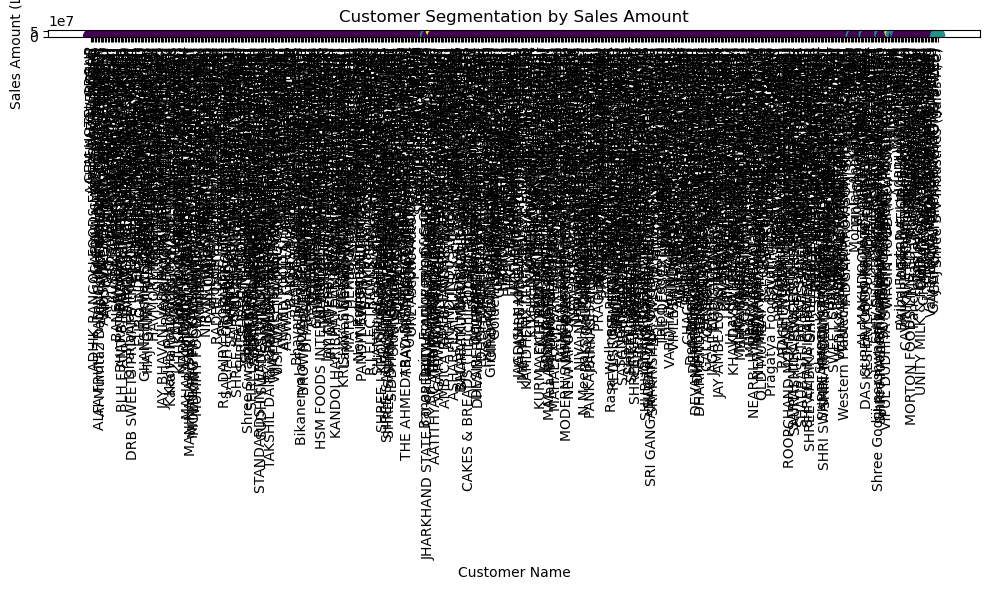

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Customer_Name'], df['Sales_Amount'], c=df['Segment'], cmap='viridis', s=100)
plt.xticks(rotation=90)
plt.title("Customer Segmentation by Sales Amount")
plt.xlabel("Customer Name")
plt.ylabel("Sales Amount (Lakhs)")
plt.tight_layout()
plt.show()

In [9]:
df.to_csv("client_sales_with_segments_2025.csv", index=False)

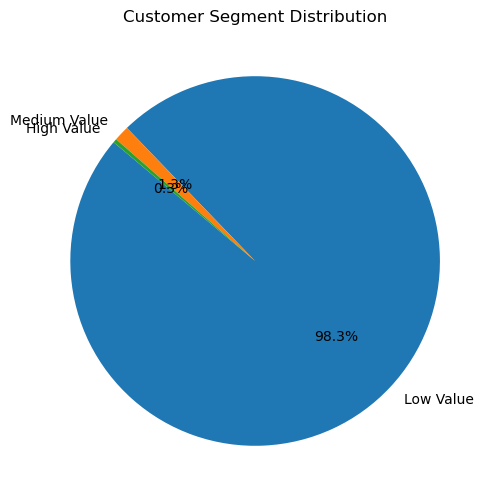

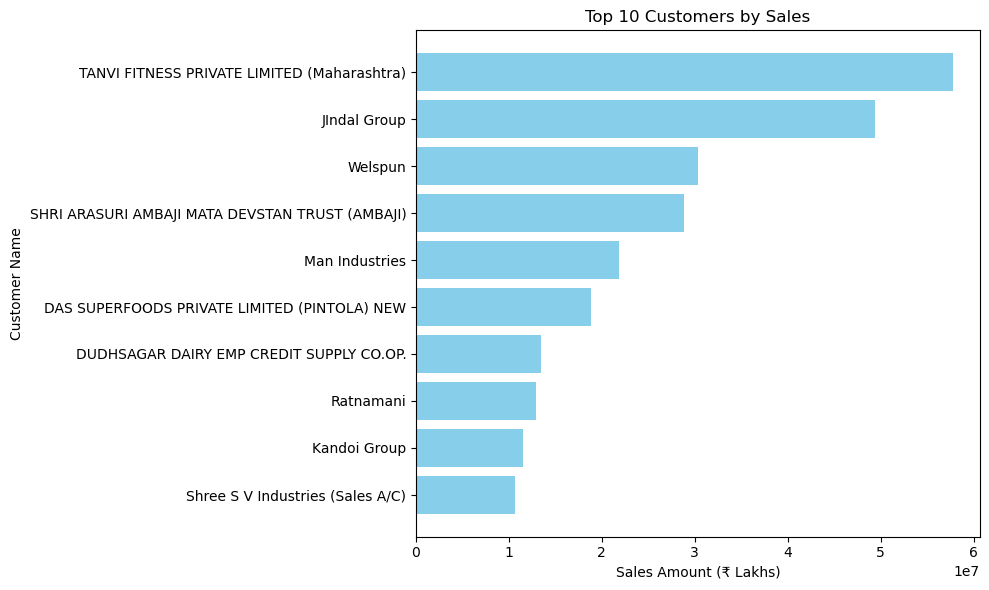

In [10]:
df = pd.read_csv("C:/Users/joshd/Documents/ML Project Sem-7/client_sales_with_segments_2025.csv")

segment_counts = df['Segment_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Customer Segment Distribution")
plt.show()

top_customers = df.sort_values(by='Sales_Amount', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_customers['Customer_Name'], top_customers['Sales_Amount'], color='skyblue')
plt.xlabel("Sales Amount (₹ Lakhs)")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Sales")
plt.gca().invert_yaxis()  # To show the highest at the top
plt.tight_layout()
plt.show()